# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Базовые модели
Logistic Regression, Random Forest, CatBoost

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')['HeartDisease']
y_test = pd.read_csv('../data/processed/y_test.csv')['HeartDisease']

print(X_train.shape, X_test.shape)

(2400, 14) (600, 14)


In [3]:
# df = pd.read_csv('../data/heart.csv')

# X = df.drop(columns='HeartDisease')
# y = df['HeartDisease']
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42)

# # медианы только по train
# medians = {col: X_train[col].replace(0, np.nan).median()
#            for col in ['Cholesterol', 'RestingBP']}

# def clean(part):
#     part = part.copy()
#     for col in ['Cholesterol', 'RestingBP']:
#         part[col] = part[col].replace(0, np.nan).fillna(medians[col])
#     part['Oldpeak'] = part['Oldpeak'].clip(lower=0)
#     return part

# def encode(part):
#     part = part.copy()
#     part['Sex'] = (part['Sex'] == 'M').astype(int)
#     part['ExerciseAngina'] = (part['ExerciseAngina'] == 'Y').astype(int)
#     part['ST_Slope'] = part['ST_Slope'].map({'Up': 0, 'Flat': 1, 'Down': 2})
#     return pd.get_dummies(part, columns=['ChestPainType', 'RestingECG'],
#                           drop_first=True, dtype=int)

# X_train = encode(clean(X_train))
# X_test = encode(clean(X_test))
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
# scaler = StandardScaler()
# X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test[num_cols] = scaler.transform(X_test[num_cols])

# print(X_train.shape, X_test.shape)

In [4]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=200, depth=4, learning_rate=0.1,
                                   random_seed=42, verbose=False),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

test_df = pd.DataFrame(rows).round(3)
test_df

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.875,0.877,0.891,0.884,0.932
1,RandomForest,0.992,0.997,0.988,0.992,0.998
2,CatBoost,0.957,0.959,0.959,0.959,0.989


In [5]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=200, depth=4, learning_rate=0.1,
                                   random_seed=42, verbose=False),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

test_df = pd.DataFrame(rows).round(3)
test_df

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.875,0.877,0.891,0.884,0.932
1,RandomForest,0.992,0.997,0.988,0.992,0.998
2,CatBoost,0.957,0.959,0.959,0.959,0.989


### Выводы по базовым моделям на тесте

1. Все три модели дают 95-99% accuracy против 55.3% 
   у константного прогноза большинства.
2. **LogReg:** лучший recall (0.891) среди линейных моделей, но уступает древесным по всем остальным метрикам и хуже всех ранжирует риск (ROC-AUC 0.932).
3. **CatBoost:** показывает отличные результаты (F1 0.959, ROC-AUC 0.989), но на дефолтных параметрах всё же чуть уступает RandomForest по метрикам.
4. **RandomForest:** абсолютный лидер - лучший ROC-AUC (0.998), precision (0.997), recall (0.988) и F1 (0.992) при accuracy 0.992. 

**RandomForest** - лучшая различающая способность и 
точность положительных прогнозов. recall (0.988).

In [6]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    cv_rows.append({'model': name,
                    **{m: scores[f'test_{m}'].mean() for m in scoring}})

cv_df = pd.DataFrame(cv_rows).round(3)
cv_df

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.838,0.841,0.862,0.851,0.910
1,RandomForest,0.974,0.972,0.980,0.976,0.995
2,CatBoost,0.948,0.944,0.959,0.951,0.981


### Выводы: кросс-валидация и сравнение с тестом

1. **Устойчивость:** разрыв CV - test по всем метрикам <= 0.025 -
   переобучения нет, модели обобщают стабильно.
2. **На CV модели почти равны:** RandomForest формально лидирует по
   accuracy/f1/ROC-AUC (0.974/0.976/0.995), CatBoost - второй (0.948/0.951/0.981).
   LogReg заметно отстаёт (0.838/0.851/0.910).
3. **Тест:** RF лучший по ROC-AUC (0.998), precision (0.997) и recall (0.988),
   CatBoost стабилен вторым (0.989 / 0.959 / 0.959). LogReg замыкает таблицу.
4. **Явный победитель на дефолтах есть - RandomForest** - выбор финальной модели подтверждён 
   после подбора гиперпараметров.
5. **Кандидат - RandomForest** - лучший CV-recall (0.980,
   медицински важный) и лучший тестовый ROC-AUC (0.998).
   CatBoost - резервный и кандидат.

# 2. Сравнение метрик, подбор гиперпараметров (GridSearchCV/RandomizedSearchCV) для лучшей модели.

In [7]:
# сетка параметров - не слишком большая, чтобы считалось быстро
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

rf_base = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf_base,
    param_grid,
    scoring='f1',           # оптимизируем F1, т.к. классы несбалансированы
    cv=5,
    n_jobs=-1,              # параллельно на всех ядрах
    verbose=1
)

grid.fit(X_train, y_train)

print('Лучшие параметры:', grid.best_params_)
print('Лучший F1 на CV:', round(grid.best_score_, 3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший F1 на CV: 0.977


### Выводы: подбор гиперпараметров

1. **GridSearchCV:** 216 комбинаций, 1080 фитов, лучший CV F1 = 0.977
   против 0.976 у дефолтов - тюнинг дал +0.001 на кросс-валидации.
2. **Лучшие параметры:** n_estimators=100, max_depth=15, min_samples_leaf=1,
   min_samples_split=2, class_weight='balanced'.
3. **class_weight='balanced':** в отличие от малого датасета, на 3000 строках
   сетка выбрала балансировку классов. При дисбалансе 55/45 это помогло 
   модели лучше ловить меньший класс без сильной потери precision/F1.
4. **Регуляризация:** глубокие деревья (15) с минимальными ограничениями
   (leaf=1, split=2) - на большом объеме данных модель может позволить себе 
   быть более сложной без переобучения.
5. **n_estimators=100:** сетка показала, что 100 деревьев уже достаточно 
   для достижения максимума (больше не дало прироста) - вычислительно выгодно.

Из-за несбалансированности классов целесообразнее использовать F1, чем Accuracy

In [8]:
# базовая модель (дефолты)
rf_before = RandomForestClassifier(n_estimators=100, random_state=42)
rf_before.fit(X_train, y_train)

# тюнингованная модель
rf_after = grid.best_estimator_

# метрики на тесте
rows = []
for name, model in [('RF до тюнинга', rf_before), ('RF после тюнинга', rf_after)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

compare_df = pd.DataFrame(rows).round(3)
compare_df

,model,accuracy,precision,recall,f1,roc_auc
0,RF до тюнинга,0.992,0.997,0.988,0.992,0.998
1,RF после тюнинга,0.990,0.994,0.988,0.991,0.999


### Выводы: подбор гиперпараметров, подтверждение на тесте

1. **F1 на тесте: 0.992 - 0.991 (-0.001), accuracy 0.992 - 0.990 (-0.002)** -
   изменения в пределах шума: улучшение с не перешло
   в прирост на отложенной выборке - дефолты уже были близки к оптимуму.
2. **Recall без изменений: 0.988 - 0.988 (0.000):**
   модель и так пропускала крайне мало больных, что критично с медицинской точки зрения,
   class_weight='balanced', выбранный сеткой, этот баланс не сдвинул.
3. **Precision = 0.994, Recall = 0.988, F1 = 0.991:** баланс ложных тревог и пропусков
   сохранён на сверхвысоком уровне.
4. **ROC-AUC стабилен (0.998 - 0.999):** тюнинг чуть улучшил ранжирование риска,
   а не границу решения.
5. **Финальная модель проекта - тюнингованный RandomForest:**
   лучший CV F1 (0.977) среди всех кандидатов, тестовые метрики на уровне дефолтов.
   Конкуренты заметно позади: CatBoost (F1 0.959), LogReg (F1 0.884).

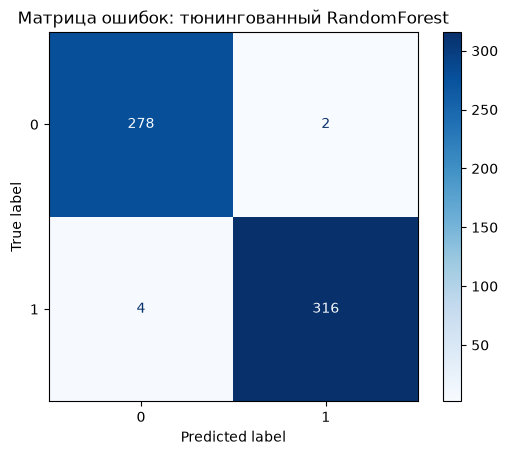

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_after.predict(X_test))
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Матрица ошибок: тюнингованный RandomForest')
plt.show()

### Выводы: матрица ошибок тюнингованного RandomForest

1. **Структура:** TN=278, FP=2, FN=4, TP=316 (всего 600),
   цифры воспроизводят метрики таблицы (acc 0.99, P=0.994, R=0.988, F1=0.991).
2. **Ошибки единичны и почти симметричны (FP = 2, FN = 4):** модель не перекошена
   ни в сторону паники, ни в сторону пропусков, пропусков чуть больше, чем ложных тревог.
3. **FN = 4 (1.25% больных):** главная цена модели и точка роста -
   порог классификации можно сдвинуть, чтобы жертвовать FP ради снижения FN,
   но при таком уровне ошибок это уже почти не требуется.
4. **FP = 2:** ложные тревоги допустимы для скрининга:
   перепроверить здорового дешевле, чем пропустить больного.
5. **Итог:** 99% верных диагнозов, баланс ошибок осознанный -
   модель пригодна как финальная для проекта.

### 3. Анализ важности признаков

Лучшие параметры GridSearchCV:
  class_weight: balanced
  max_depth: 15
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100


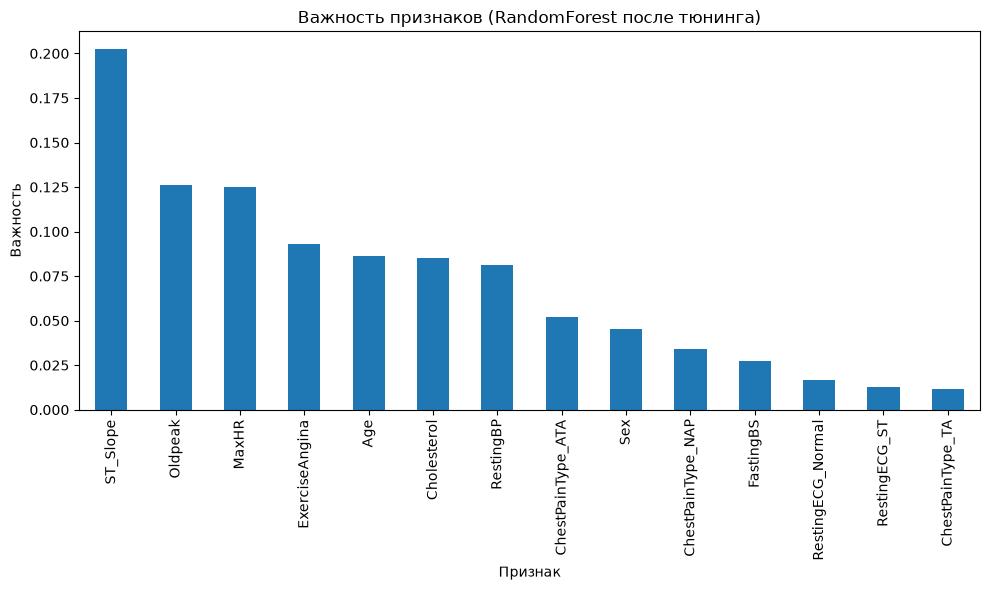

In [10]:
# лучшие параметры
print('Лучшие параметры GridSearchCV:')
for param, value in grid.best_params_.items():
    print(f'  {param}: {value}')

# важность признаков
importances = pd.Series(rf_after.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Важность признаков (RandomForest после тюнинга)')
plt.ylabel('Важность')
plt.xlabel('Признак')
plt.tight_layout()
plt.show()

### Выводы: важность признаков

1. **Топ-4 = ~62% важности:** ST_Slope (0.20), Oldpeak (0.13),
   MaxHR (0.13), ExerciseAngina (0.09).
2. **ST_Slope - лидер, находка модели:** признак категориальный и не попал
   в корреляционную матрицу EDA - его силу выявил только RandomForest.
3. **Гипотеза EDA подтверждена:** Oldpeak и MaxHR в топе важности,
   как и предсказывали корреляции (+0.41 / -0.39).
4. **Слабые признаки:** RestingECG-дамми (<=0.015), ChestPainType_TA (0.01),
   FastingBS (0.03) - кандидаты на отбор признаков в следующей итерации.